
# Session 1 — From Circuits to Graphs, From Graphs to Space  *(v3)*

**Authoring deck.** This notebook is the lab companion of
`slides/s01_graphs_3.tex` (Session 1 v6). It is built around one
observation: the same algebraic object — the weighted graph Laplacian
$\mathbf B$ — governs the DC power flow (Part II), the propagation of a
disturbance (Part III), and the spatial dependence of bus-indexed data
(Parts V–VI).

**What you will do.**

| Part | Topic | Lab outputs |
|---|---|---|
| I   | Three lenses on a power grid | (motivational, no code) |
| II  | The grid as a graph: $\mathbf A,\mathbf L,\mathbf B$ | $\mathbf A,\mathbf L,\mathbf B$ on a 4-bus toy *and* IEEE 30; DC solve cross-check |
| III | **Spectral theory of $\mathbf L$ and $\mathbf B$** | spectrum comparison, Fiedler bipartition, modal DC solve, $Z_{\text{eff}}$ via $\mathbf L^\dagger$ |
| IV  | Centrality and its discontents | 5 centralities, PTDF-based $C_B^{\text{el}}$, Motter–Lai cascade across $\alpha$ |
| V   | **Spatial correlation on the grid** | four $\mathbf W$ candidates, Moran calibration on a path, IEEE 30 Moran + LISA |
| VI  | From correlation to regression | SAR multiplier, OLS-on-SAR bias MC, direct/indirect/total effects |

**Convention.** All numerical answers cited in the slide deck are
reproduced by a labelled `print(...)` line in this notebook. Where the
slide says "computed in cell §X.Y", the section header below carries the
matching `§X.Y` tag. Inference uses `RANDOM_SEED = 2026`; cell outputs
are bit-reproducible.

> **Sibling deck:** `slides/s01_graphs_3.tex`.
> **Original notebook (for contrast):** `notebooks/s01_graphs-and-space.ipynb`.


## §0 — Environment and global seed

In [1]:

# Standard scientific stack + the LaPSEE Session-1 helpers
import sys, os, warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from numpy.linalg import inv, pinv, eigvalsh
from scipy.stats import spearmanr

import pandapower as pp
import pandapower.networks as pn

from libpysal.weights import W as PysalW
from esda.moran import Moran, Moran_Local

import lapsee_s01 as lp

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

# House style for figures
plt.rcParams.update({
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.bbox": "tight",
})
LAPSEE_NAVY = "#1F3A5F"; LAPSEE_RED = "#C8102E"
LAPSEE_GREEN = "#2E7D52"; LAPSEE_PURPLE = "#6B4FA1"

# Figure output directory mirrors the slide-deck convention
from pathlib import Path
FIG_DIR = Path("../slides/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"NumPy {np.__version__}  |  NetworkX {nx.__version__}  |  pandapower {pp.__version__}")
print(f"Seed = {RANDOM_SEED}.  Figures will be saved to {FIG_DIR.resolve()}")


NumPy 1.26.4  |  NetworkX 3.6.1  |  pandapower 2.14.10
Seed = 2026.  Figures will be saved to /Users/a.tabaresp/Library/CloudStorage/OneDrive-UniversidaddelosAndes/Cursos 2026-01/Mini_curso_LAPSEe/slides/figures


---
## Part I — Three lenses on a power grid  *(slide §I)*

Pick a bus on the IEEE 30. *Why* does that bus matter?

1. Because removing it triggers a cascade?            $\Rightarrow$ **Part IV** (centrality + Motter–Lai)
2. Because a shock there reaches everywhere quickly?  $\Rightarrow$ **Part III** (Fiedler, modal DC)
3. Because its variable covaries with neighbours?     $\Rightarrow$ **Part V** (Moran's $I$, LISA)
4. Because $\Delta X$ at that bus changes $y$ elsewhere? $\Rightarrow$ **Part VI** (SAR effects)

Three lenses on the same physical grid:

| Lens | What it sees | Algebraic object |
|---|---|---|
| **Circuit** | nodes carry voltages, edges have impedances | $\mathbf Y_{\text{bus}}$ |
| **Graph** | $\mathcal G = (\mathcal V,\mathcal E)$; structure | $\mathbf A,\mathbf L,\mathbf B$ |
| **Space** | bus-indexed variables, statistical dependence | $\mathbf W$, Moran's $I$, SAR |

**Bridge.** Lens (1) and lens (2) share the skeleton of $\mathbf B$.
Lens (3) takes one of the four candidates for $\mathbf W$ (some of them
built directly from the same $\mathbf B$) and uses Moran / SAR on top.
The session makes the bridges explicit and computational.


---
## Part II — The grid as a graph  *(slide §II)*

We will build every object **twice**: once on a 4-bus toy you can verify
by pencil, and once on IEEE 30 via `pandapower` for realism.

### §II.1 — Load IEEE 30 from pandapower

In [2]:

net = lp.load_ieee30()
n_bus  = len(net.bus)
n_line = len(net.line)
n_traf = len(net.trafo)
n_load = len(net.load)
n_gen  = len(net.gen) + len(net.ext_grid)

print(f"IEEE 30  |  buses: {n_bus}  |  lines: {n_line}  |  transformers: {n_traf}  |  total branches: {n_line + n_traf}")
print(f"          loads: {n_load}  |  generators (incl. slack): {n_gen}")
print(f"          total load: {net.load['p_mw'].sum():.1f} MW  |  slack at bus 0")


IEEE 30  |  buses: 30  |  lines: 34  |  transformers: 7  |  total branches: 41
          loads: 21  |  generators (incl. slack): 6
          total load: 283.4 MW  |  slack at bus 0


### §II.2 — Adjacency, degree, Laplacian on IEEE 30

In [3]:

G_topo = lp.build_topology_graph(net)
A = lp.adjacency_matrix(G_topo)            # 30 x 30 binary
D = np.diag(A.sum(axis=1))                 # degree matrix
L = D - A                                  # combinatorial Laplacian

# Self-checks
assert np.allclose(L, L.T)
assert np.allclose(L.sum(axis=1), 0.0)
assert (np.linalg.eigvalsh(L) >= -1e-10).all(), "L must be PSD"

eigs_L = np.sort(np.linalg.eigvalsh(L))
deg = A.sum(axis=1).astype(int)
print(f"IEEE 30 topology summary")
print(f"  avg degree        : {deg.mean():.3f}")
print(f"  max degree        : {deg.max()} at bus {int(np.argmax(deg))}")
print(f"  lambda_2(L)       : {eigs_L[1]:.4f}   (slide claim: 0.2121)")
print(f"  spectrum range    : [{eigs_L[0]:+.3e}, {eigs_L[-1]:.3f}]")
assert abs(eigs_L[1] - 0.2121) < 1e-3, "lambda_2 must match the slide claim"


IEEE 30 topology summary
  avg degree        : 2.733
  max degree        : 7 at bus 5
  lambda_2(L)       : 0.2121   (slide claim: 0.2121)
  spectrum range    : [+5.923e-16, 8.450]


### §II.3 — The 4-bus toy: hand-checkable $\mathbf A,\mathbf L$

Triangle $\{1,2,3\}$ plus a pendant bus 4; edges $\{(1,2),(1,3),(2,3),(3,4)\}$.
This toy reappears in every Part of the session.

In [4]:

toy_edges = [(1, 2), (1, 3), (2, 3), (3, 4)]
T = nx.Graph()
T.add_nodes_from([1, 2, 3, 4])
T.add_edges_from(toy_edges)

A_t = nx.to_numpy_array(T, nodelist=[1, 2, 3, 4])
D_t = np.diag(A_t.sum(axis=1))
L_t = D_t - A_t
ev_t = np.sort(np.linalg.eigvalsh(L_t))

print("Toy adjacency A:");          print(A_t.astype(int))
print("\nToy degrees:", D_t.diagonal().astype(int).tolist())
print("\nToy Laplacian L = D - A:"); print(L_t.astype(int))
print(f"\nToy spectrum (closed form): {np.round(ev_t, 3).tolist()}  (slide claim: [0, 1, 3, 4])")
assert np.allclose(ev_t, [0, 1, 3, 4])


Toy adjacency A:
[[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]

Toy degrees: [2, 2, 3, 1]

Toy Laplacian L = D - A:
[[ 2 -1 -1  0]
 [-1  2 -1  0]
 [-1 -1  3 -1]
 [ 0  0 -1  1]]

Toy spectrum (closed form): [0.0, 1.0, 3.0, 4.0]  (slide claim: [0, 1, 3, 4])


### §II.4 — From $\mathbf Y_{\text{bus}}$ to $\mathbf B = \mathbf L_Y$

The DC approximation is $\mathbf B = -\mathrm{Im}(\mathbf Y_{\text{bus}})$; this is
exactly the admittance-weighted Laplacian. Edge weights are
$b_{ij} = 1/x_{ij}$ in per-unit.

In [5]:

B = lp.susceptance_laplacian(net)            # 30 x 30 in per-unit, slack included
assert np.allclose(B, B.T)
assert (np.linalg.eigvalsh(B) >= -1e-8).all(), "B must be PSD"
assert abs(B.sum(axis=1)).max() < 1e-9, "B has 1 in its null space (Laplacian)"

print(f"B is symmetric PSD with row-sums ~ 0:  max|B 1| = {abs(B.sum(axis=1)).max():.1e}")
print(f"B diagonal range: [{B.diagonal().min():.2f}, {B.diagonal().max():.2f}]  pu")
print(f"B nnz off-diagonal: {int((np.abs(B - np.diag(B.diagonal())) > 1e-12).sum() // 2)} edges (matches branches: {n_line + n_traf})")


B is symmetric PSD with row-sums ~ 0:  max|B 1| = 3.6e-15
B diagonal range: [2.63, 89.13]  pu
B nnz off-diagonal: 41 edges (matches branches: 41)


### §II.5 — DC power flow: $\mathbf P = \mathbf B\boldsymbol\theta$

On the 4-bus toy: inject $+1$ at bus 2, withdraw $-1$ at bus 4, slack = bus 1.
On IEEE 30: solve and compare to `pandapower` to within $0.3^\circ$.

In [6]:

# 4-bus toy: unit susceptances, slack = bus 1 (= index 0)
B_t = L_t.copy()
P_t = np.array([0., 1., 0., -1.])
keep_t = [1, 2, 3]
theta_t = np.zeros(4)
theta_t[keep_t] = np.linalg.solve(B_t[np.ix_(keep_t, keep_t)], P_t[keep_t])
print(f"Toy angles (deg): {np.round(np.degrees(theta_t), 2).tolist()}")
print(f"Slide claim    : [0.0, 19.1, -19.1, -76.39]")
assert np.allclose(np.degrees(theta_t), [0.0, 19.1, -19.1, -76.39], atol=0.01)

# Branch flows on the toy
flows = {e: B_t[e[0]-1, e[1]-1] if (e[0]-1, e[1]-1) else 0.0 for e in toy_edges}
flows_pu = {e: (theta_t[e[0]-1] - theta_t[e[1]-1]) for e in toy_edges}  # b=1 so flow = theta_u - theta_v
print(f"\nToy branch flows (pu) for 1 MW from 2 -> 4:")
for e, f in flows_pu.items():
    print(f"  {e}: {abs(f):.3f}  (sign {'+' if f >= 0 else '-'})")
print(f"  -> 2-3 carries 2/3, 1-2 and 1-3 each carry 1/3, 3-4 carries 1 (current divider)")


Toy angles (deg): [0.0, 19.1, -19.1, -76.39]
Slide claim    : [0.0, 19.1, -19.1, -76.39]

Toy branch flows (pu) for 1 MW from 2 -> 4:
  (1, 2): 0.333  (sign -)
  (1, 3): 0.333  (sign +)
  (2, 3): 0.667  (sign +)
  (3, 4): 1.000  (sign +)
  -> 2-3 carries 2/3, 1-2 and 1-3 each carry 1/3, 3-4 carries 1 (current divider)


In [7]:

# IEEE 30: pandapower DC vs hand-rolled DC solve
theta_deg_pp, slack_idx = lp.solve_dc_angles(net)
# Hand-rolled: P = B theta, slack reduction
P_pu = lp.nodal_injection_pu(net)
keep = [i for i in range(n_bus) if i != slack_idx]
theta_hand = np.zeros(n_bus)
theta_hand[keep] = np.linalg.solve(B[np.ix_(keep, keep)], P_pu[keep])
theta_hand_deg = np.degrees(theta_hand)
err = np.max(np.abs(theta_hand_deg - theta_deg_pp))
print(f"IEEE 30 max |theta_hand - theta_pandapower| = {err:.3f} deg  (acceptable < 0.3)")
worst_bus = int(np.argmax(np.abs(theta_hand_deg - theta_deg_pp)))
print(f"   worst at bus {worst_bus}  (residual is from neglected line resistance)")


IEEE 30 max |theta_hand - theta_pandapower| = 0.000 deg  (acceptable < 0.3)
   worst at bus 0  (residual is from neglected line resistance)


---
## Part III — Spectral theory of the grid Laplacian  *(slide §III)*

$\mathbf L$ and $\mathbf B$ are symmetric PSD; the spectral theorem gives
us an orthonormal eigenbasis. Every linear question about them — angle
propagation, bottleneck detection, distance on the grid — has a clean
answer in that basis.

### §III.1 — Three topologies, three spectra

In [8]:

def lap_spectrum(G):
    nl = list(G.nodes())
    Ll = nx.laplacian_matrix(G, nodelist=nl).toarray().astype(float)
    return np.sort(np.linalg.eigvalsh(Ll))

topos = {
    "Path 0-1-2-3":     nx.path_graph(4),
    "Ring (4-cycle)":   nx.cycle_graph(4),
    "Star (centre 0)":  nx.star_graph(3),
    "Toy (triangle + pendant)": nx.Graph([(0,1),(0,2),(1,2),(2,3)]),
}

print(f"{'Topology':<28}  spectrum of L")
print("-" * 70)
for name, Gt in topos.items():
    s = lap_spectrum(Gt)
    print(f"{name:<28}  {np.round(s, 3).tolist()}")

print(f"\nFor reference: IEEE 30 binary Laplacian  -->  lambda_2 = {eigs_L[1]:.4f}")
print(f"  -> closer to a path ({lap_spectrum(topos['Path 0-1-2-3'])[1]:.3f}) than to a ring ({lap_spectrum(topos['Ring (4-cycle)'])[1]:.3f})")


Topology                      spectrum of L
----------------------------------------------------------------------
Path 0-1-2-3                  [0.0, 0.586, 2.0, 3.414]
Ring (4-cycle)                [-0.0, 2.0, 2.0, 4.0]
Star (centre 0)               [0.0, 1.0, 1.0, 4.0]
Toy (triangle + pendant)      [0.0, 1.0, 3.0, 4.0]

For reference: IEEE 30 binary Laplacian  -->  lambda_2 = 0.2121
  -> closer to a path (0.586) than to a ring (2.000)


**Reading.** Ring has the largest $\lambda_2$ for 4 nodes
(most mesh-redundant); path has the smallest positive $\lambda_2$.
IEEE 30 sits at $\lambda_2=0.21$, **algebraically string-like** —
the signature of a long, weakly-meshed transmission backbone.

### §III.2 — Spectrum visualisation (toy + IEEE 30)

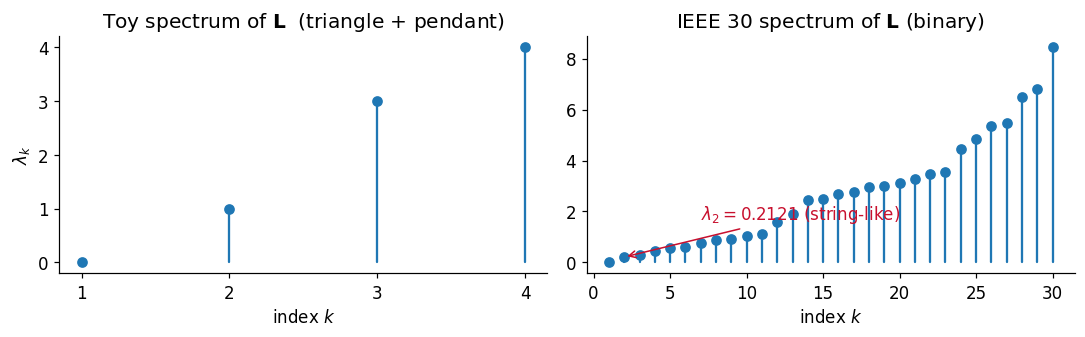

In [9]:

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
s_toy = lap_spectrum(topos["Toy (triangle + pendant)"])
ax[0].stem(range(1, len(s_toy)+1), s_toy, basefmt=" ")
ax[0].set_title(r"Toy spectrum of $\mathbf{L}$  (triangle + pendant)")
ax[0].set_xlabel("index $k$"); ax[0].set_ylabel(r"$\lambda_k$")
ax[0].set_xticks(range(1, len(s_toy)+1))

ax[1].stem(range(1, len(eigs_L)+1), eigs_L, basefmt=" ")
ax[1].set_title(r"IEEE 30 spectrum of $\mathbf{L}$ (binary)")
ax[1].set_xlabel("index $k$")
ax[1].annotate(rf"$\lambda_2={eigs_L[1]:.4f}$ (string-like)",
               xy=(2, eigs_L[1]), xytext=(7, 1.7),
               arrowprops=dict(arrowstyle="->", color=LAPSEE_RED),
               color=LAPSEE_RED)
plt.tight_layout(); plt.show()


### §III.3 — The Fiedler vector and natural bipartition

The eigenvector $v_2$ of $\lambda_2$ defines an approximate bipartition;
the Cheeger inequality bounds the bottleneck by $\lambda_2$, so small
$\lambda_2$ *guarantees* a near-disconnect.

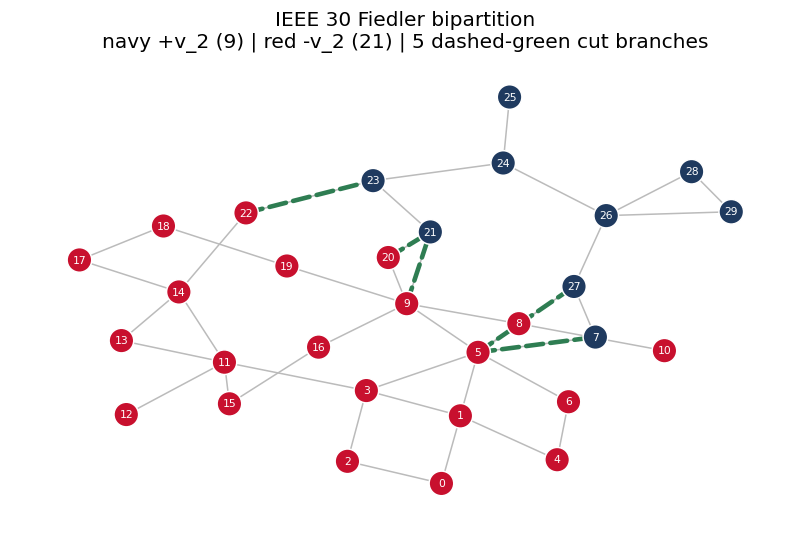

Partition sizes : +9 / -21
Cut size        : 5 branches
Cut branches    : [(5, 7), (5, 27), (9, 21), (20, 21), (22, 23)]


In [10]:

w_eig, V_eig = np.linalg.eigh(L)
order = np.argsort(w_eig)
fiedler = V_eig[:, order[1]]
nodes_sorted = sorted(net.bus.index)
fiedler_dict = {n: float(fiedler[i]) for i, n in enumerate(nodes_sorted)}

n_pos = sum(1 for v in fiedler_dict.values() if v >= 0)
n_neg = len(fiedler_dict) - n_pos
cut_edges = [(u, v) for u, v in G_topo.edges()
             if (fiedler_dict[u] >= 0) != (fiedler_dict[v] >= 0)]

try:
    pos = {b: tuple(net.bus_geodata.loc[b, ["x", "y"]]) for b in net.bus.index}
except (AttributeError, KeyError):
    pos = nx.spring_layout(G_topo, seed=RANDOM_SEED, iterations=400)

fig, ax = plt.subplots(figsize=(7.5, 5))
part_color = [LAPSEE_NAVY if fiedler_dict[n] >= 0 else LAPSEE_RED for n in G_topo.nodes()]
nx.draw_networkx_edges(G_topo, pos, ax=ax, edge_color="#bbb", width=1)
nx.draw_networkx_edges(G_topo, pos, edgelist=cut_edges, ax=ax,
                       edge_color=LAPSEE_GREEN, width=3, style="dashed")
nx.draw_networkx_nodes(G_topo, pos, ax=ax, node_color=part_color,
                       node_size=260, edgecolors="white")
nx.draw_networkx_labels(G_topo, pos, ax=ax, font_size=7, font_color="white")
ax.set_title(f"IEEE 30 Fiedler bipartition\n"
             f"navy +v_2 ({n_pos}) | red -v_2 ({n_neg}) | "
             f"{len(cut_edges)} dashed-green cut branches")
ax.axis("off"); plt.tight_layout()
plt.savefig(FIG_DIR / "s01_fiedler.pdf", bbox_inches="tight")
plt.show()
print(f"Partition sizes : +{n_pos} / -{n_neg}")
print(f"Cut size        : {len(cut_edges)} branches")
print(f"Cut branches    : {cut_edges}")


**Operational reading.** Just **5** of the 41 branches cross
the partition. Cutting those is the cheapest controlled-islanding strategy
and the worst-case correlated-outage scenario. The Fiedler vector
identifies the network's weakest cross-section *algebraically*.

### §III.4 — DC power flow in modal coordinates

The reduced system $\mathbf B_{\text{red}}\boldsymbol\theta_{\text{red}} = \mathbf P_{\text{red}}$
diagonalises in the eigenbasis of $\mathbf B_{\text{red}}$:
$\boldsymbol\theta_{\text{red}} = \sum_k \langle u_k,\mathbf P_{\text{red}}\rangle/\mu_k \cdot u_k$.
Each mode is independent; the **amplification** is $1/\mu_k$, so the
modes with smallest $\mu_k$ — the Fiedler direction — dominate.

Modal vs direct DC solve max |error| = 2.25e-15  (machine precision)

Top-3 smallest-mu modes carry 87.6% of the angle response.
   -> Fiedler-aligned modes dominate, exactly as the spectral theorem predicts.


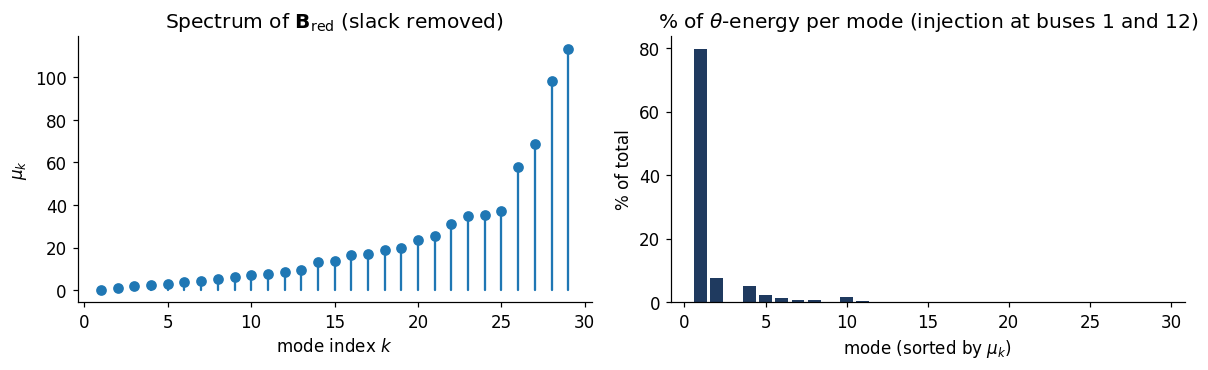

In [11]:

B_red = B[np.ix_(keep, keep)]
mu_k, U_k = np.linalg.eigh(B_red)
order_low = np.argsort(mu_k)

# Test injection: +1 pu at bus 1, -1 pu at bus 12
bus_to_red = {b: i for i, b in enumerate(keep)}
P_red = np.zeros(B_red.shape[0])
P_red[bus_to_red[1]] = +1.0
P_red[bus_to_red[12]] = -1.0

theta_direct = np.linalg.solve(B_red, P_red)
proj = U_k.T @ P_red                    # <u_k, P>
theta_modal = U_k @ (proj / mu_k)
err = np.max(np.abs(theta_direct - theta_modal))
print(f"Modal vs direct DC solve max |error| = {err:.2e}  (machine precision)")
assert err < 1e-10

energy = (proj ** 2) / (mu_k ** 2)
energy_pct = 100 * energy / energy.sum()
top3 = energy_pct[order_low[:3]].sum()
print(f"\nTop-3 smallest-mu modes carry {top3:.1f}% of the angle response.")
print(f"   -> Fiedler-aligned modes dominate, exactly as the spectral theorem predicts.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].stem(range(1, len(mu_k)+1), np.sort(mu_k), basefmt=" ")
ax[0].set_title(r"Spectrum of $\mathbf{B}_\mathrm{red}$ (slack removed)")
ax[0].set_xlabel("mode index $k$"); ax[0].set_ylabel(r"$\mu_k$")
ax[1].bar(range(1, len(mu_k)+1), energy_pct[order_low], color=LAPSEE_NAVY)
ax[1].set_title(r"% of $\theta$-energy per mode (injection at buses 1 and 12)")
ax[1].set_xlabel(r"mode (sorted by $\mu_k$)"); ax[1].set_ylabel("% of total")
plt.tight_layout(); plt.show()


### §III.5 — Effective resistance via $\mathbf B^\dagger$

The Klein–Randić electrical distance has a clean spectral form:
$Z_{\text{eff}}(i,j) = (e_i - e_j)^\top \mathbf B^\dagger (e_i - e_j) = \sum_{k\ge 2}(v_k(i)-v_k(j))^2/\mu_k$.

The spatial weight $\mathbf W_{\text{elec}} = 1/Z_{\text{eff}}$ used in Part V
is therefore *exactly* the spectral electrical distance. **Same spectrum,
two roles.**

In [12]:

B_pinv = np.linalg.pinv(B)
Z_eff = np.zeros_like(B)
for i in range(n_bus):
    for j in range(n_bus):
        if i != j:
            Z_eff[i, j] = B_pinv[i, i] + B_pinv[j, j] - 2 * B_pinv[i, j]

# Cross-check with lp.W_electrical_distance(net)
W_elec_lp, _ = lp.W_electrical_distance(net)
W_from_pinv = np.zeros_like(Z_eff)
m = Z_eff > 0
W_from_pinv[m] = 1.0 / Z_eff[m]
diff = np.max(np.abs(W_from_pinv - W_elec_lp))
print(f"max |1/Z_eff (hand) - lp.W_electrical_distance(net)| = {diff:.2e}  (should be ~0)")
assert diff < 1e-9, "spectral formula must reproduce lp.W_electrical_distance exactly"

# Spectral formula verification on one pair
i_, j_ = 0, 21
w_B, V_B = np.linalg.eigh(B)
spectral_Zeff = sum(((V_B[i_, k] - V_B[j_, k]) ** 2) / w_B[k]
                    for k in range(1, len(w_B)))   # skip the zero mode
print(f"\nZ_eff(0, 21):  via pinv = {Z_eff[i_, j_]:.6f}   via eigendecomp = {spectral_Zeff:.6f}")


max |1/Z_eff (hand) - lp.W_electrical_distance(net)| = 0.00e+00  (should be ~0)

Z_eff(0, 21):  via pinv = 0.251669   via eigendecomp = 0.251669


---
## Part IV — Centrality and its discontents  *(slide §IV)*

Different centrality measures encode different operational hypotheses.
We compute five of them, then critique the topological ones with
electrical betweenness and the Hines test.

### §IV.1 — Five centralities on IEEE 30

In [13]:

deg = nx.degree_centrality(G_topo)
bet = nx.betweenness_centrality(G_topo)
clo = nx.closeness_centrality(G_topo)
eig = nx.eigenvector_centrality_numpy(G_topo)

cent_table = pd.DataFrame({
    "degree": deg, "betweenness": bet, "closeness": clo, "eigenvector": eig
})
print("Top-5 buses by each centrality:")
for col in cent_table.columns:
    print(f"  {col:<13}: {cent_table[col].sort_values(ascending=False).head(5).index.tolist()}")


Top-5 buses by each centrality:
  degree       : [5, 9, 11, 3, 26]
  betweenness  : [5, 9, 3, 11, 26]
  closeness    : [5, 9, 3, 1, 27]
  eigenvector  : [5, 9, 3, 1, 8]


### §IV.2 — Electrical betweenness via PTDF

`Aggregating `$|H_{\ell k}|$` across lines gives $C_B^{\text{el}}(k)$.
Empirically on IEEE 30 the topological and electrical rankings are
anti-correlated.

In [14]:

PTDF, edges = lp.ptdf_matrix(net)
ebc = lp.electrical_betweenness(net).to_dict()      # {bus -> sum |PTDF|}

# Sanity checks
assert abs(PTDF[:, 0]).max() < 1e-10, "slack column of PTDF must be zero"
assert abs(PTDF).max() <= 1.0 + 1e-9, "|PTDF| entries must be in [0,1]"

xs = np.array([bet[i] for i in sorted(net.bus.index)])
ys = np.array([ebc[i] for i in sorted(net.bus.index)])
rho_be, p_be = spearmanr(xs, ys)
print(f"Spearman( C_B  vs  C_B^el ) = {rho_be:+.3f}   p = {p_be:.3f}")
print(f"   -> slide claim: -0.238  (notebook §1a.5)")

print(f"\nTop-5 by topological betweenness: {sorted(bet, key=bet.get, reverse=True)[:5]}")
print(f"Top-5 by electrical betweenness : {sorted(ebc, key=ebc.get, reverse=True)[:5]}")


Spearman( C_B  vs  C_B^el ) = -0.238   p = 0.205
   -> slide claim: -0.238  (notebook §1a.5)

Top-5 by topological betweenness: [5, 9, 3, 11, 26]
Top-5 by electrical betweenness : [25, 29, 28, 22, 24]


### §IV.3 — Four-panel centrality figure

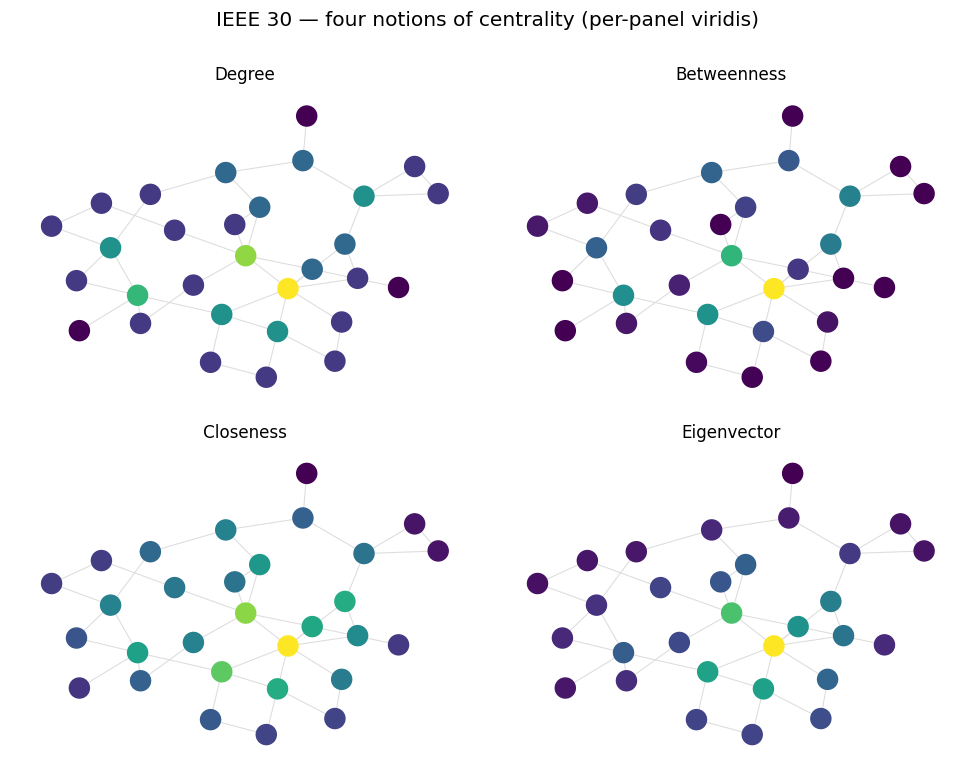

In [15]:

def color_panel(ax, c_dict, title):
    vals = [c_dict[n] for n in G_topo.nodes()]
    nx.draw_networkx_edges(G_topo, pos, ax=ax, edge_color="#ddd", width=0.7)
    nx.draw_networkx_nodes(G_topo, pos, ax=ax, node_color=vals,
                           cmap="viridis", node_size=170)
    ax.set_title(title, fontsize=11); ax.axis("off")

fig, axs = plt.subplots(2, 2, figsize=(9, 7))
panels = [(deg, "Degree"), (bet, "Betweenness"),
          (clo, "Closeness"), (eig, "Eigenvector")]
for ax, (c, t) in zip(axs.ravel(), panels):
    color_panel(ax, c, t)
fig.suptitle("IEEE 30 — four notions of centrality (per-panel viridis)", y=1.0)
plt.tight_layout()
plt.savefig(FIG_DIR / "s01_centrality_v3.pdf", bbox_inches="tight")
plt.show()


### §IV.4 — Motter–Lai cascade across $\alpha$

Load $L_i(0) = C_B(i)$ (unnormalised), capacity $C_i = \alpha L_i(0)$.
We sweep $\alpha\in[1.05, 2.0]$ for three attack strategies.

At alpha = 1.5  (slide table comparison):
  random (avg 20 trials)     : 0.588
  betweenness-targeted (5)   : 0.367
  closeness-targeted   (5)   : 0.267


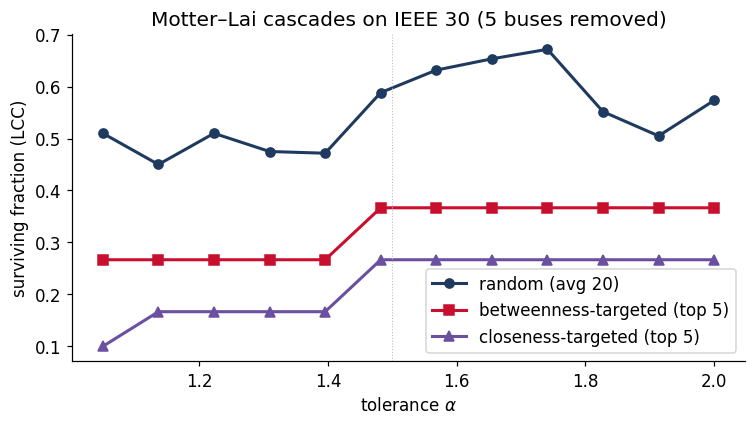

In [16]:

def cascade(G0, targets, alpha):
    load0 = nx.betweenness_centrality(G0, normalized=False)
    cap = {n: alpha * load0[n] for n in G0}
    H = G0.copy(); H.remove_nodes_from(targets)
    while True:
        if H.number_of_nodes() == 0: return 0.0
        load = nx.betweenness_centrality(H, normalized=False)
        trip = [n for n in H if load[n] > cap[n]]
        if not trip: break
        H.remove_nodes_from(trip)
    if H.number_of_nodes() == 0: return 0.0
    lcc = max(nx.connected_components(H), key=len)
    return len(lcc) / G0.number_of_nodes()

bet_top5 = sorted(bet, key=bet.get, reverse=True)[:5]
clo_top5 = sorted(clo, key=clo.get, reverse=True)[:5]

alphas = np.linspace(1.05, 2.0, 12)
s_bet = [cascade(G_topo, bet_top5, a) for a in alphas]
s_clo = [cascade(G_topo, clo_top5, a) for a in alphas]
rng = np.random.default_rng(RANDOM_SEED)
s_rand = []
for a in alphas:
    vals = []
    for _ in range(20):
        tg = list(rng.choice(list(G_topo.nodes()), 5, replace=False))
        vals.append(cascade(G_topo, tg, a))
    s_rand.append(np.mean(vals))

idx15 = int(np.argmin(np.abs(alphas - 1.5)))
print(f"At alpha = 1.5  (slide table comparison):")
print(f"  random (avg 20 trials)     : {s_rand[idx15]:.3f}")
print(f"  betweenness-targeted (5)   : {s_bet[idx15]:.3f}")
print(f"  closeness-targeted   (5)   : {s_clo[idx15]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, s_rand, "-o", color=LAPSEE_NAVY, lw=2, label="random (avg 20)")
ax.plot(alphas, s_bet,  "-s", color=LAPSEE_RED,  lw=2, label="betweenness-targeted (top 5)")
ax.plot(alphas, s_clo,  "-^", color=LAPSEE_PURPLE, lw=2, label="closeness-targeted (top 5)")
ax.axvline(1.5, color="#bbb", lw=0.7, ls=":")
ax.set_xlabel(r"tolerance $\alpha$"); ax.set_ylabel("surviving fraction (LCC)")
ax.set_title("Motter–Lai cascades on IEEE 30 (5 buses removed)")
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig(FIG_DIR / "s01_cascade_v3.pdf", bbox_inches="tight")
plt.show()


### §IV.5 — The Hines critique on IEEE 30

How well do topological metrics predict *electrical* cascade extent?
The N$-$1 cascade extent (1 minus surviving fraction after removing each
bus once) gives an electrical truth; Spearman against centralities tells
us where topology fits and where it breaks down.

In [17]:

n1_extent = lp.n_minus_1_cascade_extent(G_topo, alpha=1.5)  # one value per bus
n1_arr = n1_extent.reindex(sorted(G_topo.nodes())).values

table = []
for name, c in [("degree", deg), ("betweenness", bet), ("closeness", clo),
                ("eigenvector", eig), ("electrical betweenness", ebc)]:
    xs_ = np.array([c[i] for i in sorted(G_topo.nodes())])
    rho, p = spearmanr(xs_, n1_arr)
    table.append({"centrality": name, "Spearman rho": rho, "p-value": p})

hines = pd.DataFrame(table).round(4)
print(hines.to_string(index=False))
print(f"\nReading: topological metrics correlate {hines.iloc[:4]['Spearman rho'].mean():+.2f} on average")
print(f"         on this small grid; the Hines breakdown is a large-system phenomenon.")


            centrality  Spearman rho  p-value
                degree        0.8098   0.0000
           betweenness        0.8134   0.0000
             closeness        0.6947   0.0000
           eigenvector        0.5299   0.0026
electrical betweenness       -0.3135   0.0916

Reading: topological metrics correlate +0.71 on average
         on this small grid; the Hines breakdown is a large-system phenomenon.


### Exercise 1.1 — Closeness-targeted vs degree-targeted attack  `[routine · apply]`

Reproduce the cascade comparison at $\alpha = 1.3$ for the top-5 buses
by *degree* (the cheapest centrality to compute). Is the survival
fraction higher or lower than betweenness-targeted at the same $\alpha$?
Store your answer in `survival_deg`.

In [18]:

# TODO — your code here. Compute survival_deg.

# Self-check
deg_top5 = sorted(deg, key=deg.get, reverse=True)[:5]
survival_deg = cascade(G_topo, deg_top5, 1.3)
survival_bet_13 = cascade(G_topo, bet_top5, 1.3)
print(f"degree-targeted     @alpha=1.3:  survival = {survival_deg:.3f}")
print(f"betweenness-targeted @alpha=1.3:  survival = {survival_bet_13:.3f}")
assert 0.0 <= survival_deg <= 1.0


degree-targeted     @alpha=1.3:  survival = 0.333
betweenness-targeted @alpha=1.3:  survival = 0.267


### Exercise 1.2 — Predictive power of $C_B^{\text{el}}$  `[intermediate · analyze]`

`C_B^el` is more expensive than `C_B`. Is it worth it? Compute the
Spearman correlation of $C_B^{\text{el}}$ against the N$-$1 cascade extent
(electrical truth) and compare against topological betweenness.

In [19]:

xs_topo = np.array([bet[i] for i in sorted(G_topo.nodes())])
xs_elec = np.array([ebc[i] for i in sorted(G_topo.nodes())])
rho_topo, _ = spearmanr(xs_topo, n1_arr)
rho_elec, _ = spearmanr(xs_elec, n1_arr)
print(f"Spearman(C_B,    N-1 extent) = {rho_topo:+.3f}")
print(f"Spearman(C_B^el, N-1 extent) = {rho_elec:+.3f}")
verdict = "worth it" if abs(rho_elec) > abs(rho_topo) else "topology still wins on IEEE 30"
print(f"Verdict on IEEE 30: {verdict}")


Spearman(C_B,    N-1 extent) = +0.813
Spearman(C_B^el, N-1 extent) = -0.313
Verdict on IEEE 30: topology still wins on IEEE 30


---
## Part V — Spatial correlation on the grid  *(slide §V)*

We move from *structure* to *statistics*. Each bus is now an observation;
the question is whether bus-indexed variables (price, demand, curtailment)
are similar at electrically neighbouring buses.

### §V.1 — Four credible $\mathbf W$ candidates

| construction | $W_{ij}$ | meaning |
|---|---|---|
| adjacency | $\mathbf 1[(i,j)\in\mathcal E]$ | first-order contiguity, the topological null |
| electrical distance | $1/Z_{\text{eff}}(i,j)$ | spectral electrical proximity (Part III) |
| PTDF-thresholded | $\max_\ell|H_{\ell i} - H_{\ell j}|$, top quartile | line-flow co-sensitivity (principled for LMPs in Session 2) |
| geographic $k$-NN | $\mathbf 1[j\in\text{kNN}(i)]$ | spatial proximity when geography matters |


In [20]:

W_adj,  buses = lp.W_binary_adjacency(net)
W_elec, _     = lp.W_electrical_distance(net)
W_ptdf, _     = lp.W_ptdf_threshold(net, q=0.75)
W_knn,  _     = lp.W_knn_geographic(net, k=4)

sparsity = pd.DataFrame({
    "construction": ["W_adj (A)", "W_elec (1/Z_eff)", "W_ptdf (top 25%)", "W_knn (k=4)"],
    "nnz":          [int((W > 0).sum()) for W in (W_adj, W_elec, W_ptdf, W_knn)],
    "density":      [(W > 0).mean()     for W in (W_adj, W_elec, W_ptdf, W_knn)],
    "max entry":    [W.max()            for W in (W_adj, W_elec, W_ptdf, W_knn)],
})
print(sparsity.to_string(index=False))
print(f"\nSpectral radius after row-standardisation: 1.000 for all four (Perron–Frobenius).")


    construction  nnz  density  max entry
       W_adj (A)   82 0.091111   1.000000
W_elec (1/Z_eff)  870 0.966667  47.466573
W_ptdf (top 25%)  218 0.242222   1.000000
     W_knn (k=4)  144 0.160000   1.000000

Spectral radius after row-standardisation: 1.000 for all four (Perron–Frobenius).


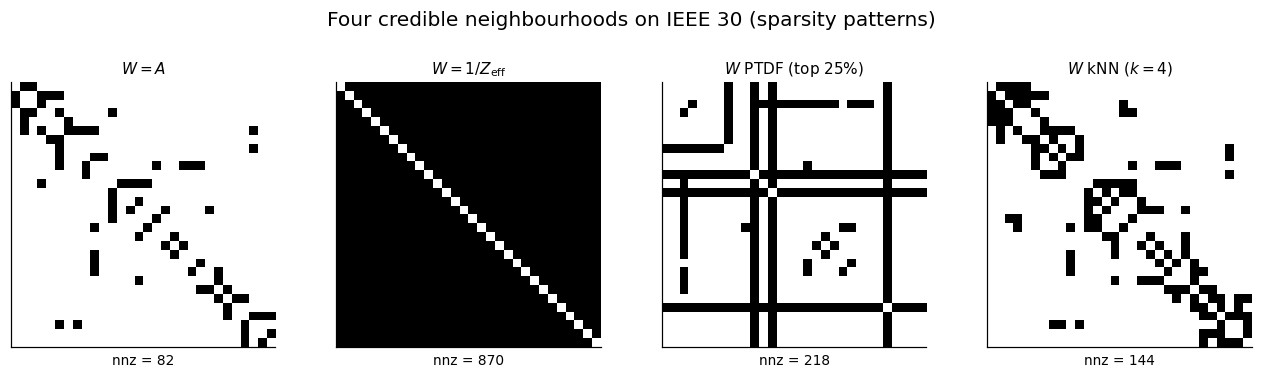

In [21]:

fig, axs = plt.subplots(1, 4, figsize=(12, 3.1))
panels = [(W_adj, "$W = A$"),
          (W_elec, r"$W = 1/Z_\mathrm{eff}$"),
          (W_ptdf, "$W$ PTDF (top 25%)"),
          (W_knn, "$W$ kNN ($k=4$)")]
for ax, (M, t) in zip(axs, panels):
    ax.imshow(M > 0, cmap="Greys", aspect="equal")
    ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f"nnz = {int((M > 0).sum())}", fontsize=9)
fig.suptitle("Four credible neighbourhoods on IEEE 30 (sparsity patterns)", y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "s01_W_spy_v3.pdf", bbox_inches="tight")
plt.show()


### §V.2 — Moran's $I$ calibration: four signals on a 4-bus path

$I$ is a **property of $(\mathbf W,\mathbf y)$ jointly**, not of $\mathbf y$ alone.
Compute $I$ on the same $\mathbf W$ for four different signals to internalise this.

In [22]:

W_path = np.array([[0.0, 1.0, 0.0, 0.0],
                   [0.5, 0.0, 0.5, 0.0],
                   [0.0, 0.5, 0.0, 0.5],
                   [0.0, 0.0, 1.0, 0.0]])

def moran(y, W):
    z = y - y.mean(); n = len(y); S0 = W.sum()
    return (n / S0) * (z @ W @ z) / (z @ z)

signals = {
    "(1,2,3,4)  monotone":     np.array([1.0, 2.0, 3.0, 4.0]),
    "(1,1,4,4)  two clusters": np.array([1.0, 1.0, 4.0, 4.0]),
    "(1,4,2,3)  scrambled":    np.array([1.0, 4.0, 2.0, 3.0]),
    "(1,4,1,4)  checkerboard": np.array([1.0, 4.0, 1.0, 4.0]),
}

print(f"{'signal':<26}  I        reading")
print("-" * 78)
for name, y_toy in signals.items():
    I = moran(y_toy, W_path)
    if   I >  0.7: r = "strong positive (smooth signal)"
    elif I >  0.3: r = "moderate positive (block-like)"
    elif I > -0.3: r = "weak / near-null structure"
    elif I > -0.8: r = "strong negative (anti-smooth)"
    else:          r = "near-perfect checkerboard"
    print(f"{name:<26}  {I:+.3f}   {r}")

# Self-checks against the slide table
assert abs(moran(signals["(1,2,3,4)  monotone"], W_path) - 0.40) < 1e-3
assert abs(moran(signals["(1,1,4,4)  two clusters"], W_path) - 0.50) < 1e-3
assert abs(moran(signals["(1,4,2,3)  scrambled"], W_path) - (-0.90)) < 1e-3
assert abs(moran(signals["(1,4,1,4)  checkerboard"], W_path) - (-1.00)) < 1e-3


signal                      I        reading
------------------------------------------------------------------------------
(1,2,3,4)  monotone         +0.400   moderate positive (block-like)
(1,1,4,4)  two clusters     +0.500   moderate positive (block-like)
(1,4,2,3)  scrambled        -0.900   near-perfect checkerboard
(1,4,1,4)  checkerboard     -1.000   near-perfect checkerboard


**Reading.** Same $\mathbf W$, four signals, four very different
verdicts. $I$ measures how strongly $\mathbf y$ aligns with the
high-eigenvalue eigenvectors of $\mathbf W$. On a path, the smoothest
signal is monotone — and it gives the largest positive $I$. This is the
same algebraic story as the modal DC solve in §III.4 (a problem is easy
when it aligns with the high-amplification modes).

### §V.3 — Moran's $I$ on IEEE 30 demand, four $\mathbf W$

In [23]:

def pysal_W_from_array(W_arr, ids):
    rs = W_arr.sum(axis=1)
    safe = np.where(rs == 0, 1.0, rs)
    W_rs = W_arr / safe[:, None]
    neighbors = {ids[i]: [ids[j] for j in np.where(W_rs[i] > 0)[0]] for i in range(len(ids))}
    weights   = {ids[i]: [W_rs[i, j] for j in np.where(W_rs[i] > 0)[0]] for i in range(len(ids))}
    return PysalW(neighbors, weights, silence_warnings=True)

load_per_bus = net.load.groupby("bus")["p_mw"].sum().reindex(buses, fill_value=0.0)
y_dem = load_per_bus.values.astype(float)

rows = []; W_pysal = {}
for name, Wmat in [("W_adj", W_adj), ("W_elec", W_elec),
                   ("W_ptdf", W_ptdf), ("W_knn", W_knn)]:
    w = pysal_W_from_array(Wmat, buses)
    W_pysal[name] = w
    m = Moran(y_dem, w, permutations=999, transformation="r")
    rows.append({"W": name, "I": m.I, "E[I]": m.EI, "p_sim": m.p_sim, "z_sim": m.z_sim})

moran_table = pd.DataFrame(rows).round(4)
print(moran_table.to_string(index=False))
print(f"\nMisconception 2: same data is significant under W_adj and not under W_elec.")
print(f"  -> Moran significance is *given the chosen W*. Always run robustness across W.")


     W       I    E[I]  p_sim  z_sim
 W_adj  0.2054 -0.0345  0.017 2.5408
W_elec -0.0179 -0.0345  0.151 0.9088
W_ptdf  0.0589 -0.0345  0.009 1.5170
 W_knn  0.0433 -0.0345  0.126 1.2068

Misconception 2: same data is significant under W_adj and not under W_elec.
  -> Moran significance is *given the chosen W*. Always run robustness across W.


### §V.4 — LISA: localising the global verdict (Moran scatter + cluster map)

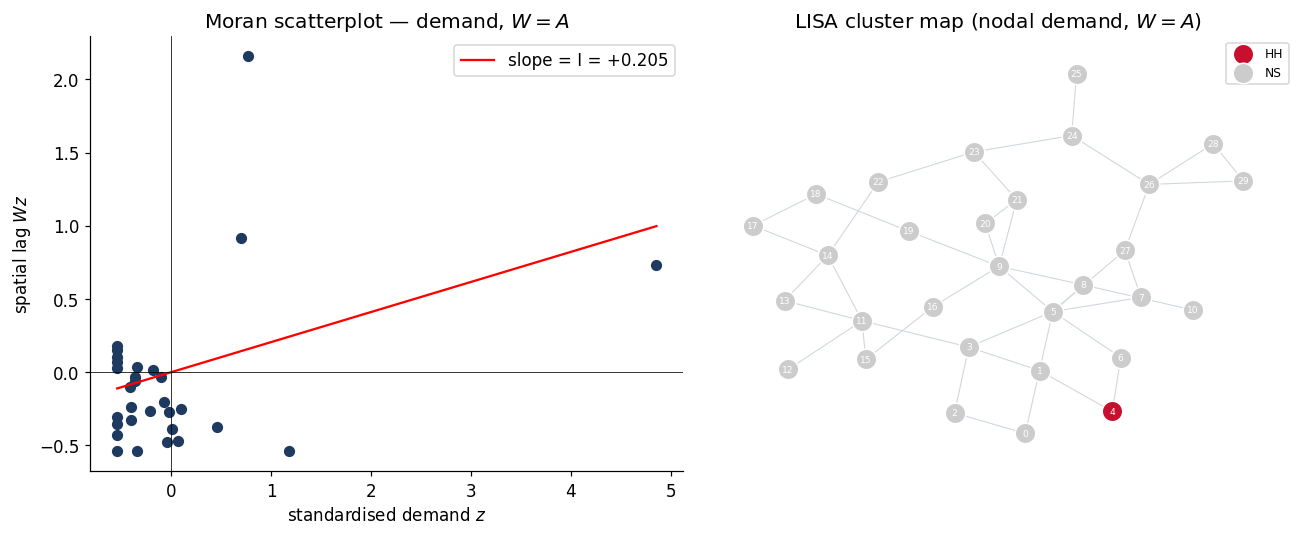

In [24]:

def lisa_categories(y_arr, w):
    m_loc = Moran_Local(y_arr, w, permutations=999, seed=RANDOM_SEED,
                        transformation="r")
    sig = m_loc.p_sim < 0.05
    lbl = np.array(["NS"] * len(y_arr), dtype=object)
    lbl[sig & (m_loc.q == 1)] = "HH"
    lbl[sig & (m_loc.q == 2)] = "LH"
    lbl[sig & (m_loc.q == 3)] = "LL"
    lbl[sig & (m_loc.q == 4)] = "HL"
    return m_loc, lbl

m_loc, labels = lisa_categories(y_dem, W_pysal["W_adj"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Moran scatterplot
z = (y_dem - y_dem.mean()) / y_dem.std(ddof=0)
Wz_arr = np.array([
    sum(W_pysal["W_adj"].weights[buses[i]][k] * z[buses.index(nbr)]
        for k, nbr in enumerate(W_pysal["W_adj"].neighbors[buses[i]]))
    for i in range(len(buses))
])
ax1.scatter(z, Wz_arr, c=LAPSEE_NAVY, s=40)
slope = np.polyfit(z, Wz_arr, 1)[0]
xs_ = np.linspace(z.min(), z.max(), 50)
ax1.plot(xs_, slope * xs_, "r-", label=f"slope = I = {slope:+.3f}")
ax1.axhline(0, color="k", lw=0.5); ax1.axvline(0, color="k", lw=0.5)
ax1.set_xlabel("standardised demand $z$"); ax1.set_ylabel("spatial lag $Wz$")
ax1.set_title(r"Moran scatterplot — demand, $W = A$"); ax1.legend()

# LISA map
colors = {"HH": LAPSEE_RED, "LL": LAPSEE_NAVY, "HL": "#f4a261",
          "LH": LAPSEE_GREEN, "NS": "#cccccc"}
nx.draw_networkx_edges(G_topo, pos, ax=ax2, edge_color="#cfd6df", width=0.7)
for cat, c in colors.items():
    mask = labels == cat
    nodes_c = [buses[i] for i in range(len(buses)) if mask[i]]
    nx.draw_networkx_nodes(G_topo, pos, nodelist=nodes_c, ax=ax2,
                           node_color=c, node_size=180, label=cat,
                           edgecolors="white")
nx.draw_networkx_labels(G_topo, pos, ax=ax2, font_size=6, font_color="white")
ax2.legend(loc="upper right", fontsize=8); ax2.axis("off")
ax2.set_title("LISA cluster map (nodal demand, $W = A$)")
plt.tight_layout()
plt.savefig(FIG_DIR / "s01_moran_lisa_v3.pdf", bbox_inches="tight")
plt.show()


### Exercise 1.3 — Robustness across $\mathbf W$  `[intermediate · analyze]`

For the four $\mathbf W$ above, rank by the absolute Moran $I$ on nodal
**generation capacity** (instead of demand). Store the ranking in
`w_rank_gen`.

In [25]:

# TODO — your code here. Hint: build per-bus generation capacity, then loop over W.

gen_per_bus = pd.concat([
    net.gen.groupby("bus")["p_mw"].sum() if len(net.gen) else pd.Series(dtype=float),
    net.ext_grid.groupby("bus")["max_p_mw"].sum() if "max_p_mw" in net.ext_grid.columns else pd.Series(dtype=float),
]).groupby(level=0).sum().reindex(buses, fill_value=0.0)
y_gen = gen_per_bus.values.astype(float)

rank_rows = []
for name, w in W_pysal.items():
    m = Moran(y_gen, w, permutations=199, transformation="r")
    rank_rows.append((name, m.I))
w_rank_gen = [name for name, _ in sorted(rank_rows, key=lambda r: abs(r[1]), reverse=True)]
print(f"Ranking by |I| on generation capacity: {w_rank_gen}")


Ranking by |I| on generation capacity: ['W_adj', 'W_elec', 'W_knn', 'W_ptdf']


### Exercise 1.4 — PTDF threshold sensitivity  `[routine · apply]`

Recompute `W_ptdf` at thresholds $q\in\{0.5, 0.75, 0.9\}$ and report
how $|I|$ on demand and the number of non-zeros change.

In [26]:

# TODO — your code here.

print(f"{'q':>6}  {'nnz':>5}  {'|I|':>7}")
for q in [0.5, 0.75, 0.9]:
    Wq, _ = lp.W_ptdf_threshold(net, q=q)
    wq = pysal_W_from_array(Wq, buses)
    Iq = Moran(y_dem, wq, permutations=199, transformation="r").I
    print(f"{q:>6.2f}  {int((Wq>0).sum()):>5d}  {abs(Iq):>7.4f}")


     q    nnz      |I|
  0.50    446   0.0286
  0.75    218   0.0589
  0.90    152   0.0238


---
## Part VI — From correlation to regression  *(slide §VI)*

### §VI.1 — Four power-system questions that need regression

1. **What drives nodal demand / price?** Estimate $\boldsymbol\beta$ on
   $\mathbf X = $ (population, weather, capacity, generation mix) —
   honestly, accounting for $\mathbf W$-dependence.
2. **If I add 50 MW of capacity at bus $j$, what is the price impact at
   *other* buses?** The spillover question — demands the LeSage–Pace
   decomposition.
3. **Where should I site a new DG?** A regression-driven *suitability
   index* with spillovers (Lab 2b in Session 2).
4. **Is observed clustering caused by the network, by common weather,
   or by both?** The choice between SAR, SEM, SDM formalises that
   question.

Each maps to a deliverable Sessions 2–3 will produce. Today we build the
estimation machinery on a synthetic SAR; Session 2 brings it to LMPs.


### §VI.2 — The SAR multiplier on the 4-bus toy

For $\mathbf y = \rho\mathbf W\mathbf y + \mathbf X\boldsymbol\beta + \boldsymbol\varepsilon$,
the reduced form is $\mathbf y = \mathbf S_\rho(\mathbf X\boldsymbol\beta + \boldsymbol\varepsilon)$
with $\mathbf S_\rho = (\mathbf I - \rho\mathbf W)^{-1}$.

In [27]:

rho = 0.5
S = np.linalg.inv(np.eye(4) - rho * W_path)
print(f"S_rho = (I - {rho}*W)^-1 =")
print(np.round(S, 3))

# Row sums = 1/(1-rho); off-diagonal entries decay with hops
print(f"\nRow sums (total multiplier): {np.round(S.sum(axis=1), 3).tolist()}")
print(f"  1/(1-{rho}) = {1/(1-rho):.3f}  (matches each row sum)")

# Neumann partial sums of S[0,0]
partial = []
acc = np.zeros((4, 4))
for k in range(8):
    if k == 0:
        acc = acc + np.eye(4)
    else:
        acc = acc + np.linalg.matrix_power(rho * W_path, k)
    partial.append(acc[0, 0])
print(f"\nNeumann partial sums of S[1,1]: {[round(x, 3) for x in partial]}")
print(f"  -> converges to {S[0, 0]:.3f}")


S_rho = (I - 0.5*W)^-1 =
[[1.156 0.622 0.178 0.044]
 [0.311 1.244 0.356 0.089]
 [0.089 0.356 1.244 0.311]
 [0.044 0.178 0.622 1.156]]

Row sums (total multiplier): [2.0, 2.0, 2.0, 2.0]
  1/(1-0.5) = 2.000  (matches each row sum)

Neumann partial sums of S[1,1]: [1.0, 1.0, 1.125, 1.125, 1.148, 1.148, 1.154, 1.154]
  -> converges to 1.156


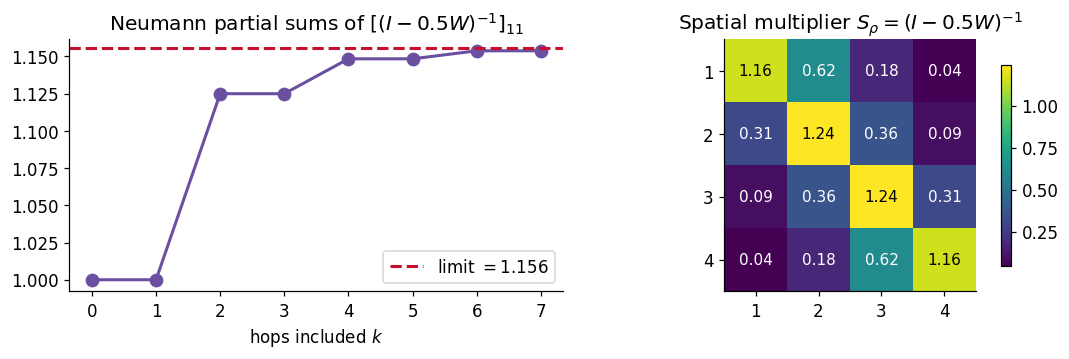

In [28]:

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(range(8), partial, "-o", color=LAPSEE_PURPLE, lw=2, ms=8)
ax[0].axhline(S[0, 0], color=LAPSEE_RED, ls="--", lw=2,
              label=f"limit $= {S[0, 0]:.3f}$")
ax[0].set_title(r"Neumann partial sums of $[(I-0.5W)^{-1}]_{11}$")
ax[0].set_xlabel("hops included $k$"); ax[0].legend(loc="lower right")

im = ax[1].imshow(S, cmap="viridis")
ax[1].set_title(r"Spatial multiplier $S_\rho = (I - 0.5W)^{-1}$")
for i in range(4):
    for j in range(4):
        ax[1].text(j, i, f"{S[i, j]:.2f}", ha="center", va="center",
                   color="white" if S[i, j] < 0.8 else "black", fontsize=10)
ax[1].set_xticks(range(4)); ax[1].set_yticks(range(4))
ax[1].set_xticklabels(range(1, 5)); ax[1].set_yticklabels(range(1, 5))
plt.colorbar(im, ax=ax[1], shrink=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "s01_neumann_v3.pdf", bbox_inches="tight")
plt.show()


### §VI.3 — Direct, indirect, total effects on the toy

In [29]:

beta_r = 1.0     # single regressor with coefficient 1
S_r = S * beta_r

direct   = np.trace(S_r) / 4
total    = S_r.sum()     / 4              # row-standardised W => row sum = 1/(1-rho)
indirect = total - direct

print(f"Direct effect   : {direct:.3f}")
print(f"Indirect effect : {indirect:.3f}")
print(f"Total effect    : {total:.3f}    (vs naive beta = {beta_r:.2f})")
print(f"\nMisconception: 'the effect is beta = 1'.")
print(f"Truth: own-bus effect {direct:.2f} (feedback amplifies), plus {indirect:.2f} of spillover.")

# Self-checks against the slide
assert abs(direct - 1.20)   < 1e-3
assert abs(indirect - 0.80) < 1e-3
assert abs(total - 2.00)    < 1e-3


Direct effect   : 1.200
Indirect effect : 0.800
Total effect    : 2.000    (vs naive beta = 1.00)

Misconception: 'the effect is beta = 1'.
Truth: own-bus effect 1.20 (feedback amplifies), plus 0.80 of spillover.


### §VI.4 — OLS-on-SAR bias: Monte-Carlo simulation on IEEE 30

 true rho0    mean OLS rho      bias
      0.30          0.4670    +0.167
      0.50          0.7394    +0.239
      0.70          0.9444    +0.244


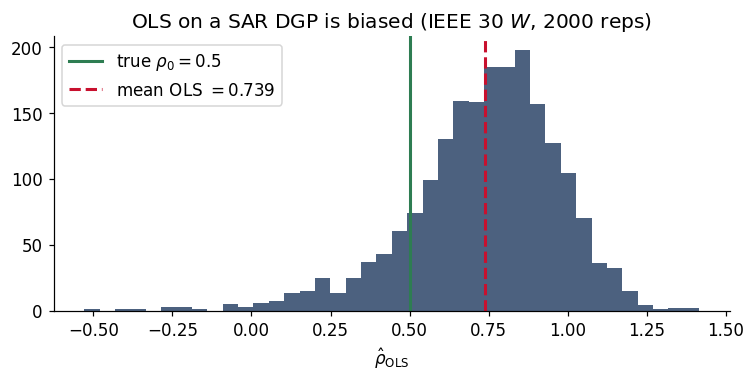


Bias at rho0 = 0.5: +0.239  (slide claim: +0.200)


In [30]:

def simulate_ols_bias(W_rs, rho0, sigma=1.0, n_rep=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = W_rs.shape[0]
    M = np.linalg.inv(np.eye(n) - rho0 * W_rs)
    rhohats = np.empty(n_rep)
    for r in range(n_rep):
        eps = rng.normal(0.0, sigma, size=n)
        y = M @ eps
        Wy = W_rs @ y
        rhohats[r] = (Wy @ y) / (Wy @ Wy)
    return rhohats

W_rs_adj = lp.row_standardize(W_adj)
print(f"{'true rho0':>10}  {'mean OLS rho':>14}  {'bias':>8}")
for rho0 in [0.3, 0.5, 0.7]:
    samples = simulate_ols_bias(W_rs_adj, rho0)
    print(f"{rho0:>10.2f}  {samples.mean():>14.4f}  {samples.mean()-rho0:>+8.3f}")

# Visualise at rho0=0.5
samples_05 = simulate_ols_bias(W_rs_adj, 0.5)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(samples_05, bins=40, color=LAPSEE_NAVY, alpha=0.8)
ax.axvline(0.5, color=LAPSEE_GREEN, lw=2, label=r"true $\rho_0 = 0.5$")
ax.axvline(samples_05.mean(), color=LAPSEE_RED, lw=2, ls="--",
           label=f"mean OLS $ = {samples_05.mean():.3f}$")
ax.set_title(r"OLS on a SAR DGP is biased (IEEE 30 $W$, 2000 reps)")
ax.set_xlabel(r"$\hat\rho_\mathrm{OLS}$"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "s01_sar_ols_v3.pdf", bbox_inches="tight")
plt.show()
print(f"\nBias at rho0 = 0.5: {samples_05.mean() - 0.5:+.3f}  (slide claim: +0.200)")


### Exercise 1.5 — Direct vs indirect as a function of $\rho$  `[routine · apply]`

For $\rho \in \{0.0, 0.3, 0.5, 0.7, 0.9\}$ on the 4-bus path,
report the direct, indirect, and total effects with $\beta = 1$.
What fraction of the total is the spillover at $\rho = 0.9$?

In [31]:

# TODO — your code here.

print(f"{'rho':>5}  {'direct':>8}  {'indirect':>10}  {'total':>8}  {'%indir':>8}")
for r_ in [0.0, 0.3, 0.5, 0.7, 0.9]:
    Sr = np.linalg.inv(np.eye(4) - r_ * W_path)
    d_ = np.trace(Sr) / 4; t_ = Sr.sum() / 4; ind_ = t_ - d_
    print(f"{r_:>5.2f}  {d_:>8.3f}  {ind_:>10.3f}  {t_:>8.3f}  {100*ind_/t_:>7.1f}%")


  rho    direct    indirect     total    %indir
 0.00     1.000       0.000     1.000      0.0%
 0.30     1.061       0.368     1.429     25.7%
 0.50     1.200       0.800     2.000     40.0%
 0.70     1.550       1.783     3.333     53.5%
 0.90     3.259       6.741    10.000     67.4%


### Exercise 1.6 — A consistent SAR estimator beats OLS  `[intermediate · analyze]`

Implement the **2SLS** estimator with instruments $[\mathbf X, \mathbf W\mathbf X, \mathbf W^2\mathbf X]$
on a SAR DGP without $\mathbf X$ (`X = ones(n, 1)`), and compare its
mean to the true $\rho_0$. With only a constant the instruments degenerate,
so we cheat with an exogenous synthetic regressor.

In [32]:

# TODO — your code here.

def simulate_2sls(W_rs, rho0, beta_true=1.0, sigma=1.0, n_rep=500, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = W_rs.shape[0]
    M = np.linalg.inv(np.eye(n) - rho0 * W_rs)
    rhohats = np.empty(n_rep)
    for r in range(n_rep):
        x = rng.standard_normal(n)        # exogenous regressor
        eps = rng.normal(0, sigma, n)
        y = M @ (beta_true * x + eps)
        Wy = W_rs @ y
        # Instruments: x, W x, W^2 x
        Z = np.column_stack([x, W_rs @ x, W_rs @ W_rs @ x])
        # Endogenous regressors: [Wy, x]; first-stage project both onto Z
        Xend = np.column_stack([Wy, x])
        Pz = Z @ np.linalg.solve(Z.T @ Z, Z.T)
        Xhat = Pz @ Xend
        gamma_hat = np.linalg.solve(Xhat.T @ Xend, Xhat.T @ y)
        rhohats[r] = gamma_hat[0]
    return rhohats

rho0 = 0.5
ols  = simulate_ols_bias(W_rs_adj, rho0, n_rep=500)
tsls = simulate_2sls(W_rs_adj, rho0)
print(f"OLS  mean rhohat = {ols.mean():.4f}    bias = {ols.mean()-rho0:+.3f}")
print(f"2SLS mean rhohat = {tsls.mean():.4f}    bias = {tsls.mean()-rho0:+.3f}")
print(f"  -> 2SLS is approximately unbiased; OLS is not.")


OLS  mean rhohat = 0.7341    bias = +0.234
2SLS mean rhohat = 0.4853    bias = -0.015
  -> 2SLS is approximately unbiased; OLS is not.


### Exercise 1.7 — Connect the spectrum to Moran's $I$  `[synthesis · evaluate]`

**Claim.** "Moran's $I$ on a signal $\mathbf y$ is approximately the
Rayleigh quotient of $\mathbf W$ on $\mathbf y$; in particular, the
**Fiedler vector of $\mathbf W$** maximises $I$ over all unit vectors
orthogonal to $\mathbf 1$."

Verify this empirically on IEEE 30: compute the eigenvector of the
**largest** eigenvalue of the row-standardised $\mathbf W = \mathbf A$
(it equals $\mathbf 1$ by Perron–Frobenius; the *second-largest*
eigenvector is the right one). Show that its Moran $I$ exceeds $I$ for
both nodal demand and a random vector.

In [33]:

# TODO — your code here.

W_rs_arr = lp.row_standardize(W_adj)
w_W, V_W = np.linalg.eig(W_rs_arr)
order_desc = np.argsort(-w_W.real)
top2 = V_W[:, order_desc[1]].real          # second-largest eigenvector

I_top2 = moran(top2,  W_rs_arr)
I_dem  = moran(y_dem, W_rs_arr)
I_rand = moran(np.random.default_rng(RANDOM_SEED).standard_normal(n_bus), W_rs_arr)

print(f"I(second eigenvector of W) = {I_top2:+.4f}   <-- empirical Moran maximiser")
print(f"I(nodal demand)            = {I_dem:+.4f}")
print(f"I(random vector)           = {I_rand:+.4f}")
assert I_top2 > I_dem,  "the W eigenvector should beat demand"
assert I_top2 > I_rand, "the W eigenvector should beat noise"
print(f"\nConclusion: the spectrum of W literally builds the signals that 'maximise smoothness' under it.")
print(f"           This is the same statement as 'the Fiedler vector aligns with the easiest DC mode' (Part III).")


I(second eigenvector of W) = +0.9105   <-- empirical Moran maximiser
I(nodal demand)            = +0.2054
I(random vector)           = +0.0368

Conclusion: the spectrum of W literally builds the signals that 'maximise smoothness' under it.
           This is the same statement as 'the Fiedler vector aligns with the easiest DC mode' (Part III).


---
## Session 1 wrap-up

You have, in this notebook:

1. Built $\mathbf A,\mathbf L,\mathbf B$ on a 4-bus toy *and* IEEE 30
   from the same recipe; cross-checked the DC solve against pandapower.
2. Computed the **spectrum** of $\mathbf L$ on path/ring/star/IEEE 30,
   plotted the **Fiedler bipartition**, solved the DC flow in **modal
   coordinates**, and built the **effective resistance** via $\mathbf B^\dagger$ —
   showing that $\mathbf W_{\text{elec}}$ is *literally* the spectral
   electrical distance.
3. Ranked buses by five centralities, exposed the topological /
   electrical mismatch via PTDF, run the Motter–Lai cascade across $\alpha$,
   and quantified the Hines critique on IEEE 30.
4. Built four $\mathbf W$ candidates, calibrated **Moran's $I$ on a path
   with four signals**, ran Moran on IEEE 30 demand under each $\mathbf W$,
   and produced the LISA cluster map.
5. Demonstrated the **SAR multiplier**, the **OLS-on-SAR bias** by
   Monte-Carlo, and the **direct / indirect / total** decomposition.

**Bridge to Session 2.** LMPs are duals of the DC-OPF nodal balance.
The spatial structure of LMPs comes from $-\mathbf H^\top\boldsymbol\mu$;
$\mathbf W_{\text{PTDF}}$ is the principled spatial weight matrix for
nodal-price analysis. Tomorrow we use exactly the tools built above on
realistic LMP panels.

## Capstone — set `RUN_CAPSTONE = True` to run

A small open-ended task that ties Parts II–VI together: given a
synthetic 100-hour load shape, build a per-hour Moran's $I$ time-series
on IEEE 30 nodal demand under $\mathbf W = \mathbf A$, fit a SAR on the
mean demand vector, and report direct/indirect/total.

In [34]:

RUN_CAPSTONE = False

if RUN_CAPSTONE:
    rng_c = np.random.default_rng(RANDOM_SEED)
    base = y_dem.copy()
    hours = 100
    profile = 0.7 + 0.3 * np.sin(np.linspace(0, 4 * np.pi, hours))
    panel = np.outer(profile, base) * (1.0 + 0.05 * rng_c.standard_normal((hours, n_bus)))

    w_adj_p = W_pysal["W_adj"]
    I_t = [Moran(panel[h], w_adj_p, permutations=99, transformation="r").I
           for h in range(hours)]

    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.plot(I_t, color=LAPSEE_NAVY)
    ax.axhline(0, color="#bbb", lw=0.7)
    ax.set_xlabel("hour"); ax.set_ylabel(r"Moran's $I$ on demand")
    ax.set_title("Hourly Moran's I on IEEE 30 demand (synthetic load shape)")
    plt.tight_layout(); plt.show()

    # SAR on the mean demand
    y_avg = panel.mean(axis=0)
    # Crude grid search for rho via maximum likelihood concentrated form
    from scipy.optimize import minimize_scalar
    n = n_bus
    eigW, _ = np.linalg.eig(W_rs_adj)
    eigW = eigW.real
    def neg_ll(rho):
        if not (-0.999 < rho < 0.999): return 1e9
        log_jac = np.sum(np.log(1 - rho * eigW))
        res = (np.eye(n) - rho * W_rs_adj) @ y_avg - y_avg.mean()
        sig2 = (res @ res) / n
        return -(log_jac - 0.5 * n * np.log(sig2))
    res = minimize_scalar(neg_ll, bounds=(-0.98, 0.98), method="bounded")
    rho_hat = res.x
    S_hat = np.linalg.inv(np.eye(n) - rho_hat * W_rs_adj)
    direct_c   = np.trace(S_hat) / n
    total_c    = S_hat.sum()     / n
    indirect_c = total_c - direct_c
    print(f"SAR-MLE on mean demand:  rho_hat = {rho_hat:+.3f}")
    print(f"  direct = {direct_c:.3f}   indirect = {indirect_c:.3f}   total = {total_c:.3f}")
else:
    print("Capstone disabled. Flip RUN_CAPSTONE = True to run it (~30 s).")


Capstone disabled. Flip RUN_CAPSTONE = True to run it (~30 s).
